# Exploratory data analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
columns = pd.read_csv("census-bureau.columns", header=None)
df = pd.read_csv("census-bureau.data", header=None)
df.columns = columns.iloc[:,0].tolist()
df = df.drop_duplicates() # there are 3229 duplicates


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196294 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         196294 non-null  int64  
 1   class of worker                             196294 non-null  object 
 2   detailed industry recode                    196294 non-null  int64  
 3   detailed occupation recode                  196294 non-null  int64  
 4   education                                   196294 non-null  object 
 5   wage per hour                               196294 non-null  int64  
 6   enroll in edu inst last wk                  196294 non-null  object 
 7   marital stat                                196294 non-null  object 
 8   major industry code                         196294 non-null  object 
 9   major occupation code                       196294 non-null  object 
 10  r

In [4]:
df.fillna({'hispanic origin': 'missing'}, inplace=True)
y = df['label']
y = y.map({'- 50000.': 0, '50000+.': 1}) # convert to 0 1
X = df.drop(columns=['label'])

## Cramer's V correlation between categorical features 

In [5]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mutual_info_score
from matplotlib.colors import LinearSegmentedColormap

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    phi2til = max(0, chi2/n - (k - 1)*(r - 1)/(n - 1))
    ktil = k - (k - 1)**2/(n - 1)
    rtil = r - (r - 1)**2/(n - 1)
    return np.sqrt(phi2til/min(ktil - 1, rtil - 1))

    
# set color map to have special value at 0.5
cmap = LinearSegmentedColormap.from_list(
    "custom",
    [(0, "blue"), (0.7, "white"), (1, "red")])



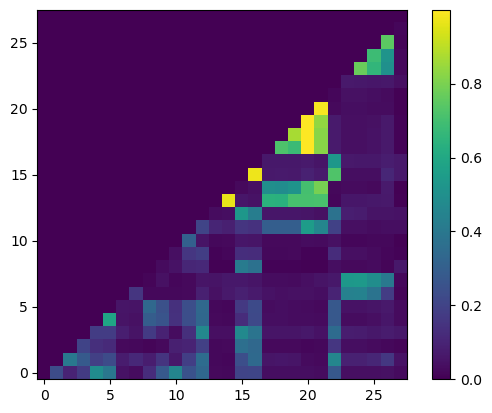

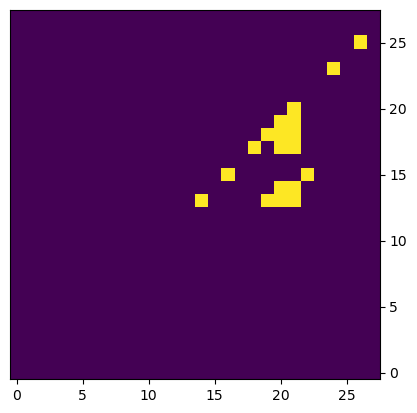

In [6]:
# calculate cramer's V in a matrix
cat_col = X.select_dtypes(exclude='number').columns.tolist()
n = len(cat_col)
cramers_v_mat = np.zeros((n,n))
for i in range(n):
    for j in range(i+1, n):
        cramers_v_mat[i][j] = cramers_v(X[cat_col[i]], X[cat_col[j]])

plt.imshow(cramers_v_mat, origin='lower')
plt.colorbar()
plt.show()


plt.imshow(cramers_v_mat> 0.7, origin='lower')
ax = plt.gca()
ax.yaxis.set_ticks_position('right')
plt.show()


class of worker


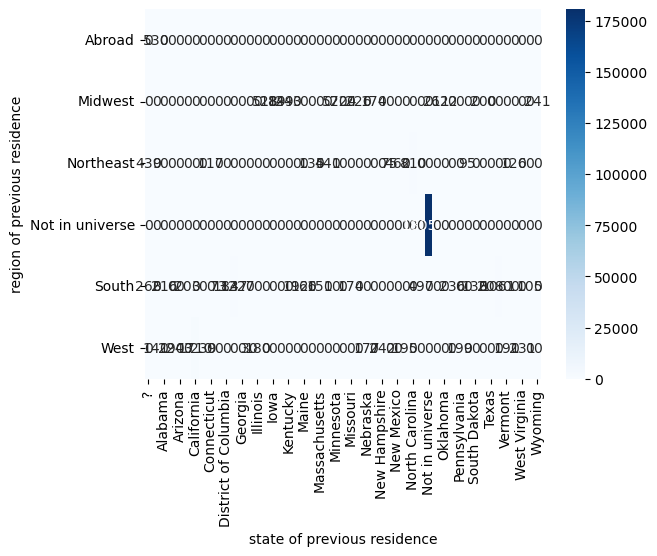

education


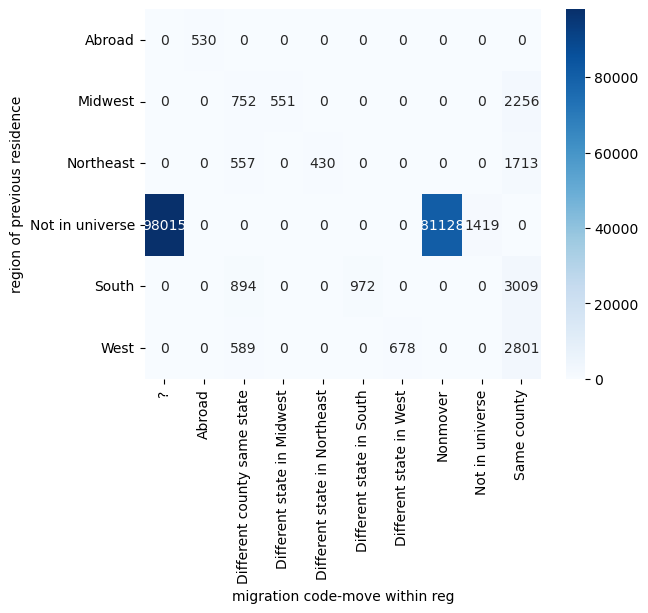

enroll in edu inst last wk


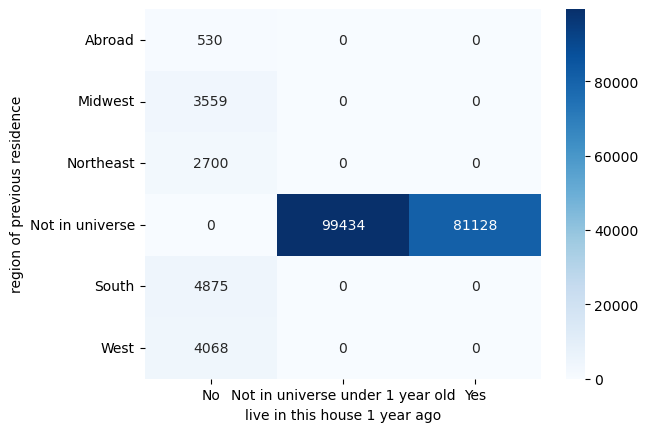

marital stat


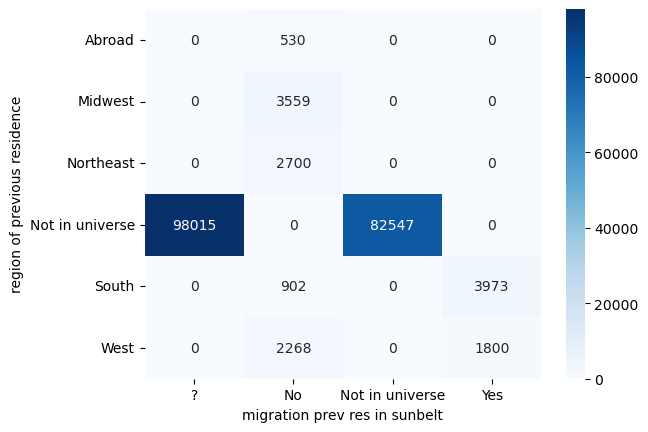

major industry code


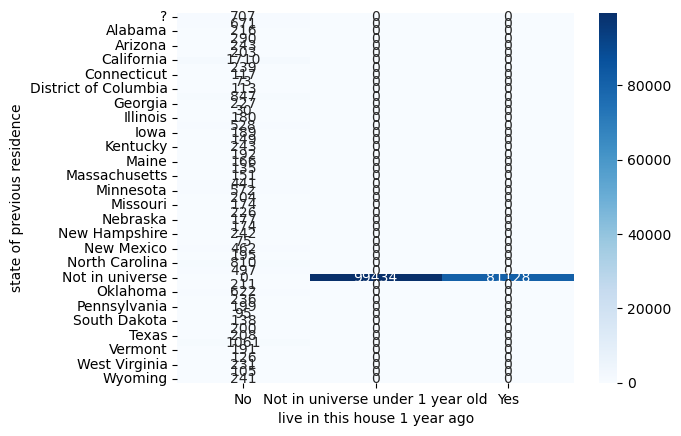

major occupation code


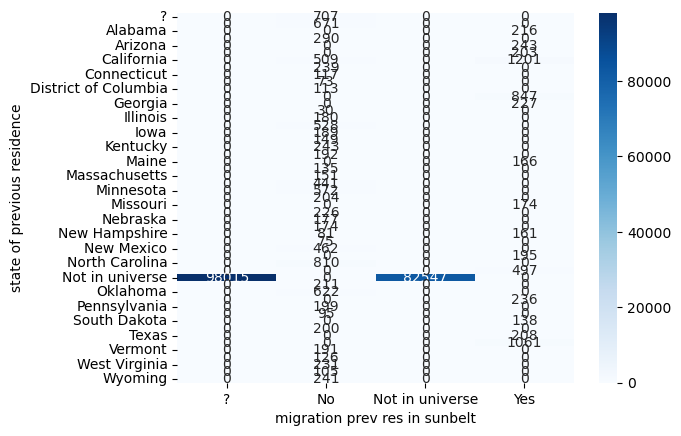

race


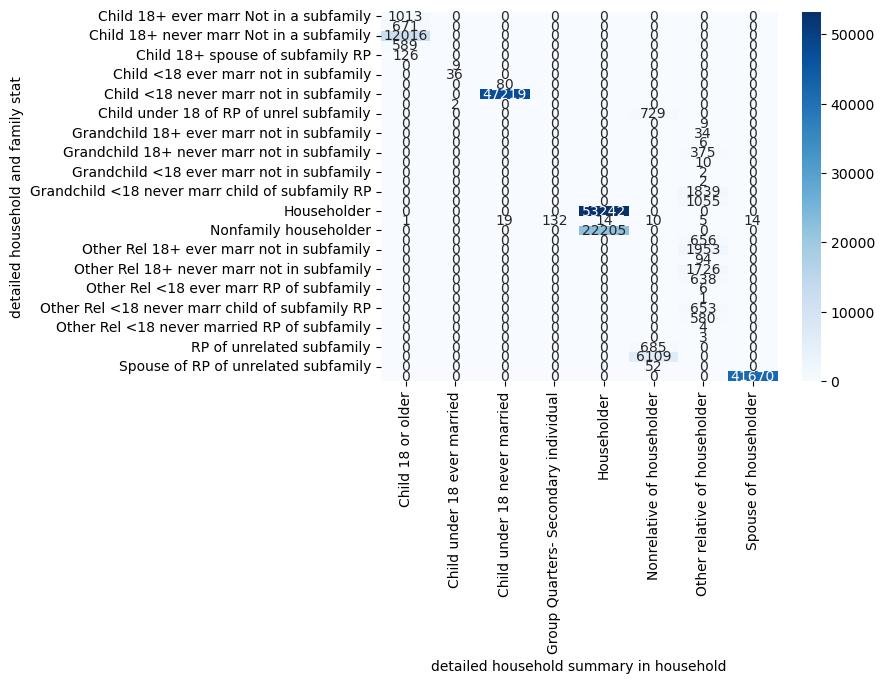

hispanic origin


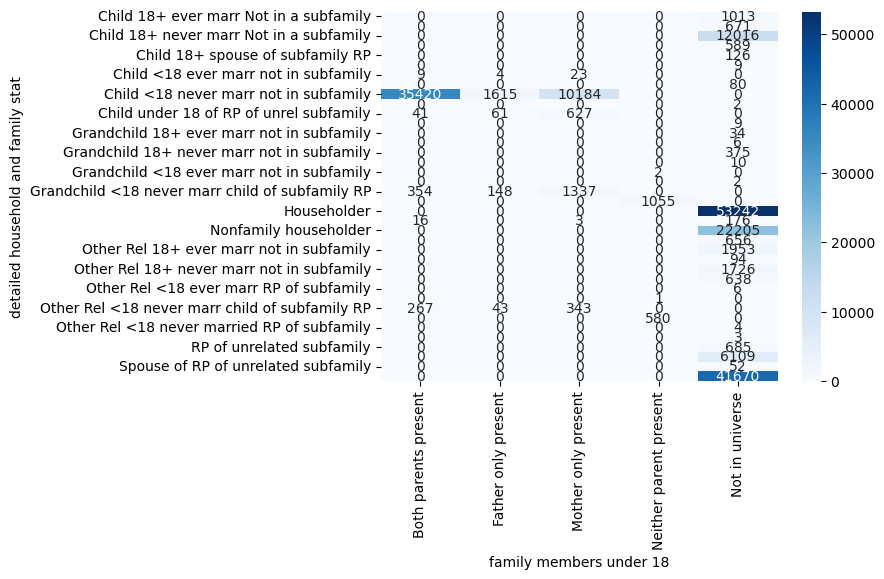

sex


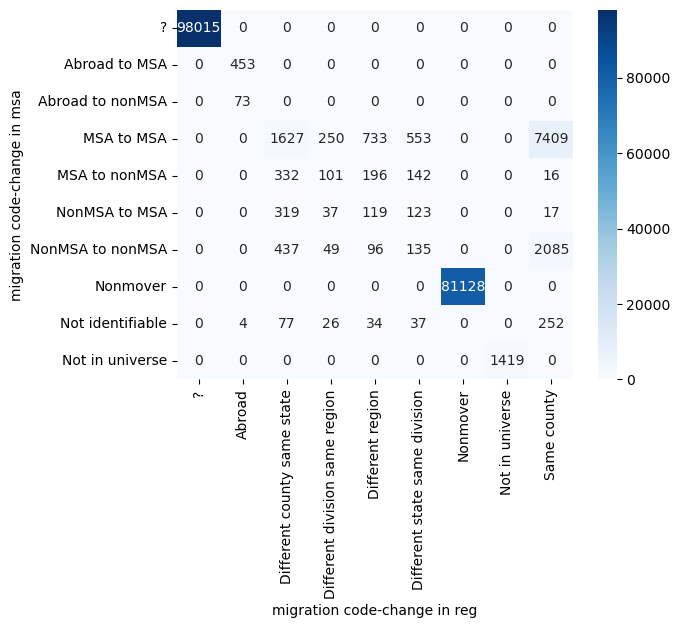

member of a labor union


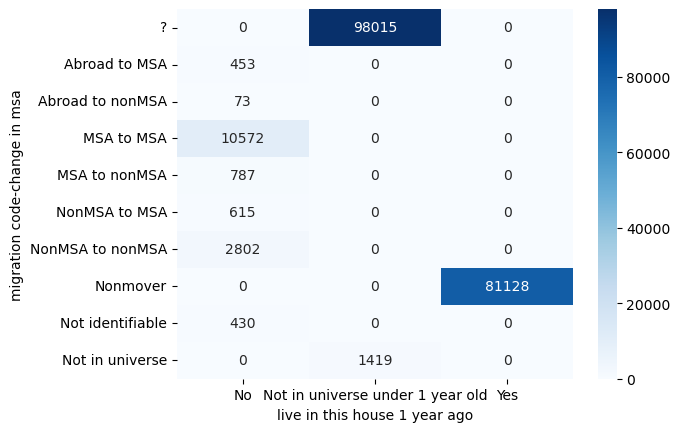

reason for unemployment


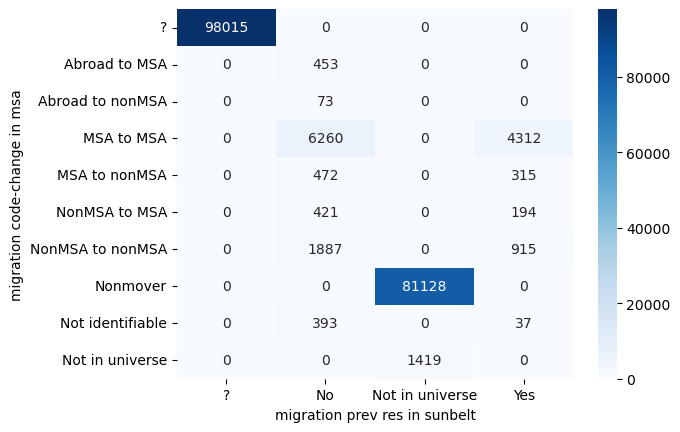

full or part time employment stat


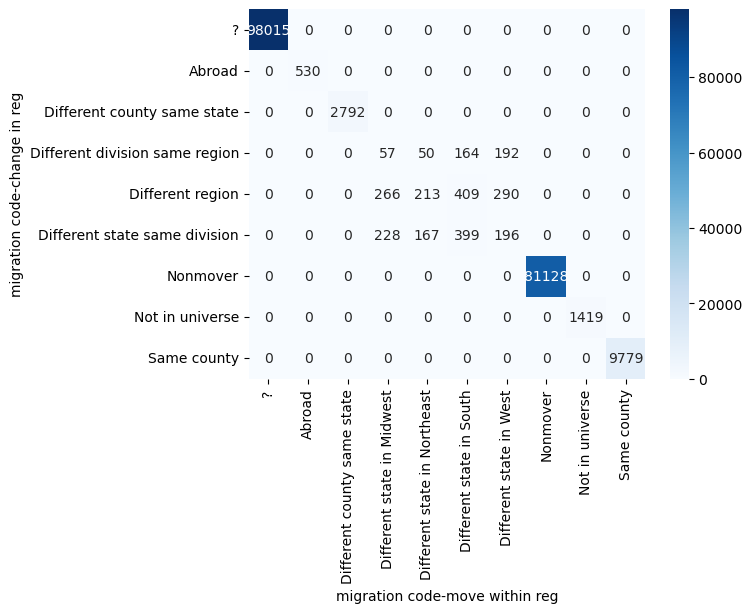

tax filer stat


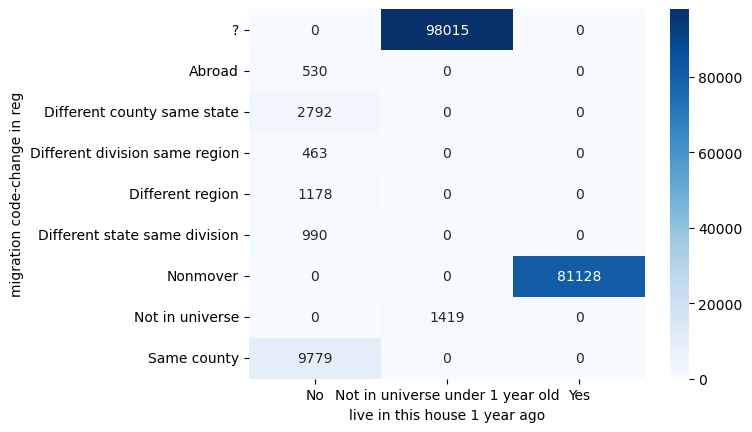

region of previous residence


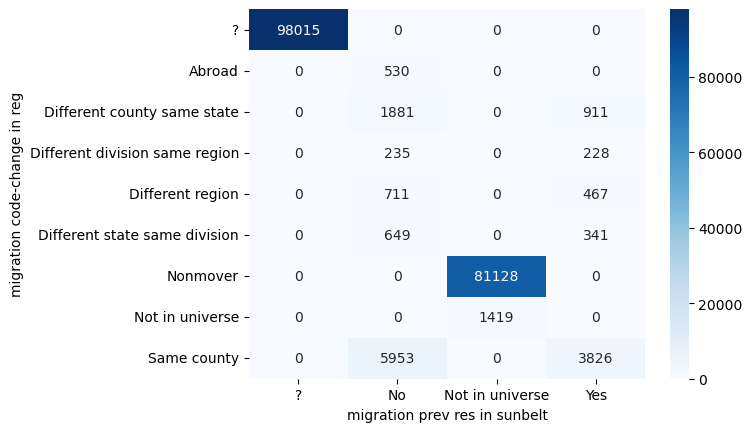

state of previous residence


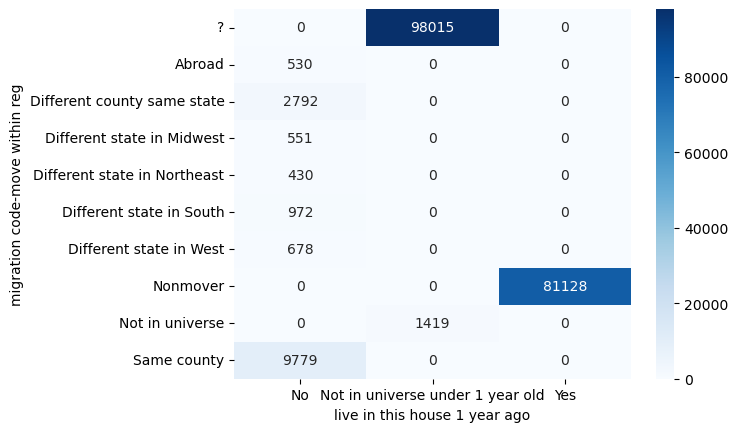

detailed household and family stat


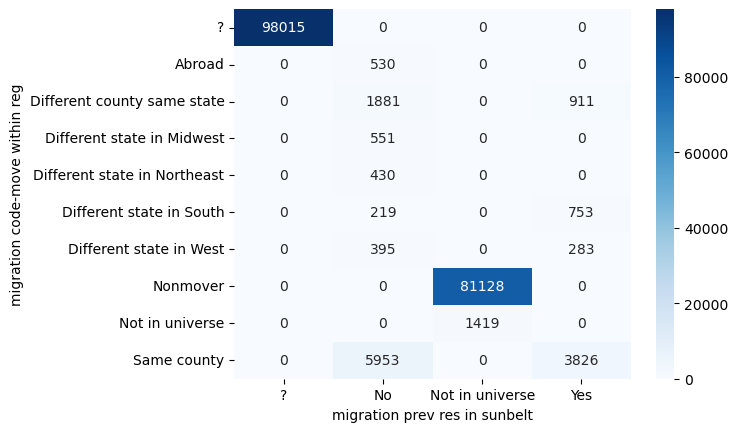

detailed household summary in household


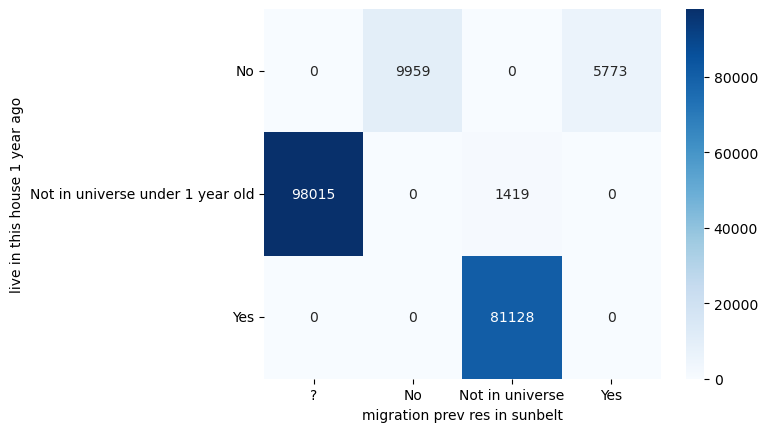

migration code-change in msa


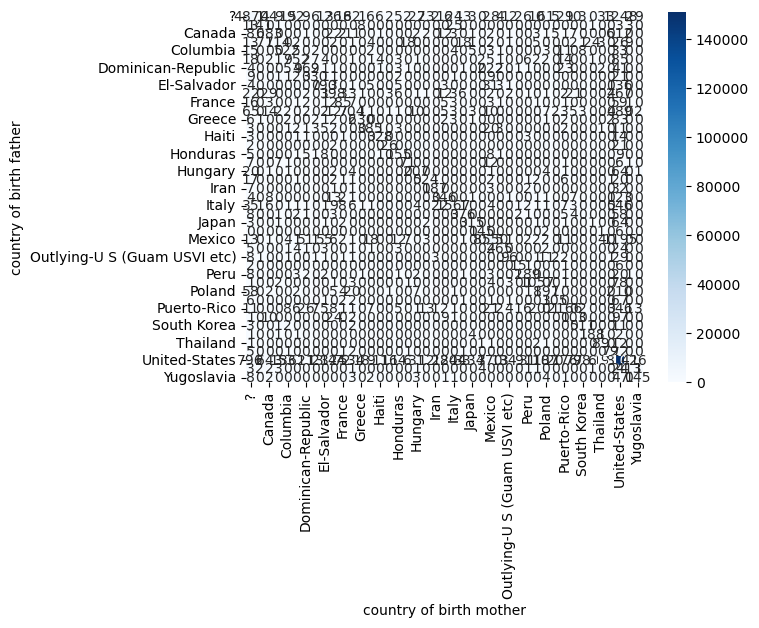

migration code-change in reg


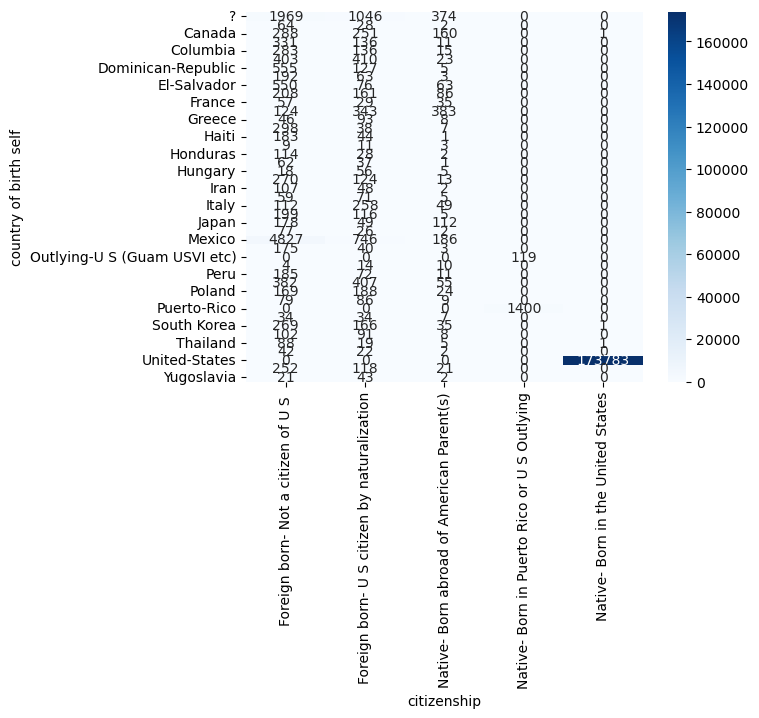

In [8]:
(r, c) = np.where(cramers_v_mat > 0.7)
for i in range(len(r)):
    print(cat_col[i])
    ct = pd.crosstab(X[cat_col[r[i]]], X[cat_col[c[i]]])
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
    plt.show()


In [ ]:
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder


def normalized_entropy(x):
    # computes entropy for a feature (already encoded as all integers)
    return mutual_info_score(x, x)/np.log(len(np.unique(x)))

cat_col = X.select_dtypes(exclude='number').columns.tolist() # col names of all categorical features
n = len(cat_col)
MI_mat = np.zeros((n,n))
for i in range(n):
    for j in range(i+1, n):
            x_enc = LabelEncoder().fit_transform(X[cat_col[i]])
            y_enc = LabelEncoder().fit_transform(X[cat_col[j]])
            h_x = normalized_entropy(x_enc)
            h_y = normalized_entropy(y_enc)
            if np.min([h_x, h_y]) > 0.1:
                  MI_mat[i][j] = mutual_info_score(x_enc, y_enc)/min(h_x, h_y)

plt.imshow(MI_mat, origin='lower')
plt.colorbar()

In [ ]:
ct = pd.crosstab(X[cat_col[14]], X[cat_col[13]])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.show()

## low cardinality categorical feature conversion 

In [ ]:
# Convert categorical features with 2 unique values or 3 unique values with order to numerical
X['sex'] = X['sex'].map({'Female':0, 'Male':1})
X['member of a labor union'] = X['member of a labor union'].map({'No':-1, 'Yes':1, 'Not in universe':0})
X['fill inc questionnaire for veteran\'s admin'] = X['fill inc questionnaire for veteran\'s admin'].map({'No':-1, 'Yes':1, 'Not in universe':0})
X['live in this house 1 year ago'] = X['live in this house 1 year ago'].map({'No':-1, 'Yes':1, 'Not in universe under 1 year old':0})

In [ ]:
categorical = X.select_dtypes(exclude='number').columns.tolist()
numerical = X.select_dtypes(include='number').columns.tolist()

print(categorical)
print(numerical)

['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship']
['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'sex', 'member of a labor union', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'live in this house 1 year ago', 'num persons worked for employer', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked

In [ ]:
for col in categorical:
    print(col, X[col].nunique())

In [ ]:
import pickle
with open("pre_split_data.pkl", "wb") as f:
    pickle.dump([X, y, categorical, numerical], f)